In [1]:
import os
import glob

from IPython.core.display import HTML

from indra_cogex.analysis.protein_analysis import explain_downstream

source_protein_name = ['CTNNB1', 'LEF1']

target_protein_names = ['GLCE','ACSL5','APCDD1','ADAMTSL2','CALML3','CEMIP2','AMOT','PLA2G4A','RCN2','TTC9','FABP4','GPCPD1','VSNL1','CRYBB1','PDZD8','FNDC3A']

output_folder = 'analysis_results'

INFO: [2024-08-15 04:28:23] numexpr.utils - NumExpr defaulting to 8 threads.


INFO: [2024-08-15 04:28:39] indra_cogex.analysis.protein_analysis - Dataframe of protiens that have INDRA relationships with HGNC:2514 that have been filtered:
        name target_type target_id       stmt_type  evidence_count  \
3904   FABP4        HGNC      3559         Complex               1   
3905   FABP4        HGNC      3559      Activation               1   
3906   FABP4        HGNC      3559      Inhibition               1   
3907   FABP4        HGNC      3559  DecreaseAmount               1   
5518    GLCE        HGNC     17855  IncreaseAmount               1   
5519    GLCE        HGNC     17855  IncreaseAmount               2   
5546    AMOT        HGNC     17810         Complex               1   
5547    AMOT        HGNC     17810         Complex               1   
6246  APCDD1        HGNC     15718         Complex               5   
6370  CALML3        HGNC      1452      Activation               1   

              stmt_hash                                          stmt

                                                 name             id  \
0   TGF beta receptor signaling in skeletal dyspla...         WP4816   
1                                             Disease  R-HSA-1643685   
2                              Metabolism of proteins   R-HSA-392499   
3                              Alzheimer 39 s disease         WP5124   
4            Alzheimer 39 s disease and miRNA effects         WP2059   
5                                Pleural mesothelioma         WP5087   
6                Hippo Merlin signaling dysregulation         WP4541   
7                              VEGFA VEGFR2 signaling         WP3888   
8   Regulation of Expression and Function of Type ...  R-HSA-9764260   
9                        Regulation of CDH11 function  R-HSA-9762292   
10         Regulation of Homotypic Cell-Cell Adhesion  R-HSA-9759476   
11        Regulation of CDH11 Expression and Function  R-HSA-9759475   
12                                Signal Transduction   R-HSA-16

INFO: [2024-08-15 04:29:17] indra_cogex.analysis.protein_analysis - These are the shared upstream bioentities between thegene list and source_protein
            curie                        name             p       mlp  \
304   chebi:39867               valproic acid  2.259326e-08  7.646021   
92    chebi:33216                 bisphenol A  9.387872e-08  7.027433   
335   chebi:28748                 doxorubicin  5.074194e-07  6.294633   
301   chebi:42588  4-hydroxyphenyl retinamide  2.585734e-06  5.587416   
538    chebi:4031               cyclosporin A  3.267658e-06  5.485763   
370   chebi:15379                    dioxygen  6.004090e-06  5.221553   
1600  chebi:15354                     choline  9.358851e-06  5.028777   
85    chebi:35549      perfluorooctanoic acid  8.601402e-06  5.065431   

             q       mlq  
304   0.001107  2.955896  
92    0.002300  2.638338  
335   0.008048  2.094298  
301   0.021113  1.675442  
538   0.022870  1.640736  
370   0.036769  1.434518  
160

{'staments_by_protein_filtered': '<table border="1" class="dataframe table table-striped table-sm">\n  <thead>\n    <tr style="text-align: right;">\n      <th></th>\n      <th>name</th>\n      <th>target_type</th>\n      <th>target_id</th>\n      <th>stmt_type</th>\n      <th>evidence_count</th>\n      <th>stmt_hash</th>\n      <th>stmt_json</th>\n      <th>evidences</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <th>3904</th>\n      <td>FABP4</td>\n      <td>HGNC</td>\n      <td>3559</td>\n      <td>Complex</td>\n      <td>1</td>\n      <td>13357222918706991</td>\n      <td>{"type": "Complex", "members": [{"name": "CTNNB1", "db_refs": {"UP": "P35222", "EGID": "1499", "HGNC": "2514", "TEXT": "\\u03b2-catenin"}}, {"name": "FABP4", "db_refs": {"UP": "P15090", "TEXT": "FABP4", "HGNC": "3559", "EGID": "2167"}}], "belief": 0.65, "evidence": [{"source_api": "sparser", "pmid": "21872687", "text": "One recent study shows that \\u03b2-catenin binds to the FABP4 promoter in preadipocyte

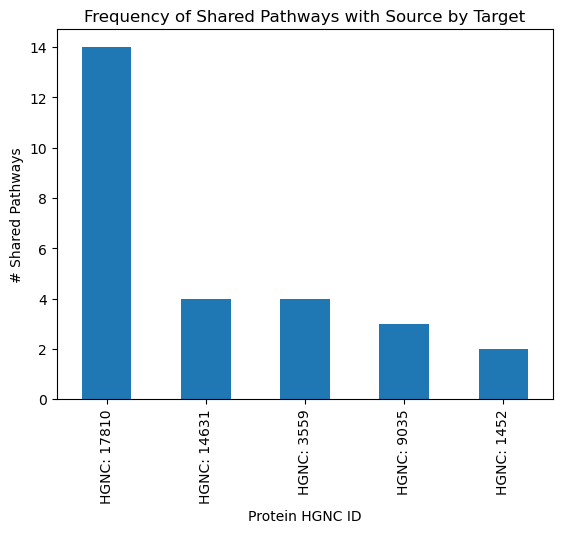

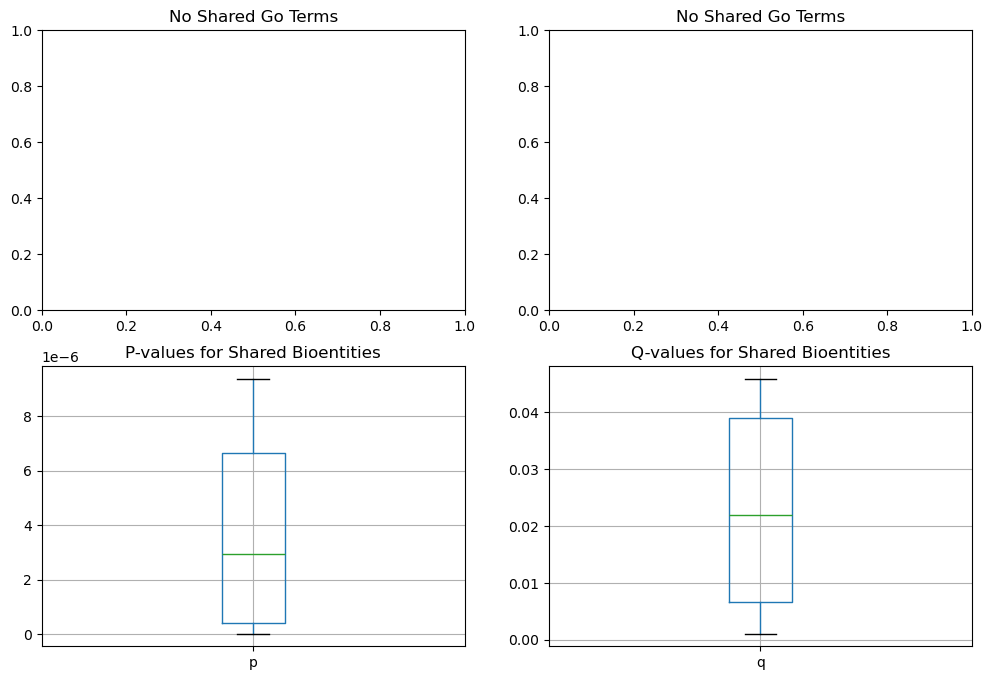

In [2]:
result = explain_downstream(source_protein_name, target_protein_names, output_folder)

In [6]:
import os
from jinja2 import Environment, FileSystemLoader
import webbrowser 

env = Environment(loader=FileSystemLoader('.')) 
template = env.get_template('protein_analysis_template.html')
output = template.render(result=result)

with open('results.html', 'w') as f:
    f.write(output)
webbrowser.open('file://' + os.path.realpath('results.html')) 

True

Look into explaining some upstreams through specific statements

In [3]:
from indra.sources import indra_db_rest
from indra.tools import assemble_corpus as ac
from indra.assemblers.html import HtmlAssembler

In [4]:
ip = indra_db_rest.get_statements(subject='LEF1')
stmts = ac.filter_gene_list(ip.statements, set(target_protein_names) - {'CTNNB1'} | {'LEF1'}, policy='all')
stmts = [s for s in stmts if len({x.name for x in s.real_agent_list()}) > 1]
ha = HtmlAssembler(stmts)
_ = ha.make_model(grouping_level='statement')
ha.save_model(os.path.join(output_folder, 'LEF1_explanations.html'))

INFO: [2024-08-09 16:09:54] indra_db_rest.query_processor - Retrieving statements that have an agent where NAME=LEF1 with role=SUBJECT.
INFO: [2024-08-09 16:09:54] indra_db_rest.request_logs - Running 0th request for statements
INFO: [2024-08-09 16:09:54] indra_db_rest.request_logs -   LIMIT: None
INFO: [2024-08-09 16:09:54] indra_db_rest.request_logs -   OFFSET: 0
INFO: [2024-08-09 16:09:55] indra_db_rest.request_logs - Running 1st request for statements
INFO: [2024-08-09 16:09:55] indra_db_rest.request_logs -   LIMIT: None
INFO: [2024-08-09 16:09:55] indra_db_rest.request_logs -   OFFSET: 500
INFO: [2024-08-09 16:09:57] indra_db_rest.request_logs - Running 2nd request for statements
INFO: [2024-08-09 16:09:57] indra_db_rest.request_logs -   LIMIT: None
INFO: [2024-08-09 16:09:57] indra_db_rest.request_logs -   OFFSET: 1000
INFO: [2024-08-09 16:09:58] indra_db_rest.request_logs - Running 3rd request for statements
INFO: [2024-08-09 16:09:58] indra_db_rest.request_logs -   LIMIT: None


In [5]:
ip = indra_db_rest.get_statements(subject='TCF7L2')
stmts = ac.filter_gene_list(ip.statements, set(target_protein_names) - {'CTNNB1'} | {'TCF7L2'}, policy='all')
stmts = [s for s in stmts if len({x.name for x in s.real_agent_list()}) > 1]
ha = HtmlAssembler(stmts)
_ = ha.make_model(grouping_level='statement')
ha.save_model(os.path.join(output_folder, 'TCF7L2_explanations.html'))

INFO: [2024-08-09 16:10:06] indra_db_rest.query_processor - Retrieving statements that have an agent where NAME=TCF7L2 with role=SUBJECT.
INFO: [2024-08-09 16:10:06] indra_db_rest.request_logs - Running 0th request for statements
INFO: [2024-08-09 16:10:06] indra_db_rest.request_logs -   LIMIT: None
INFO: [2024-08-09 16:10:06] indra_db_rest.request_logs -   OFFSET: 0
INFO: [2024-08-09 16:10:07] indra_db_rest.request_logs - Running 1st request for statements
INFO: [2024-08-09 16:10:07] indra_db_rest.request_logs -   LIMIT: None
INFO: [2024-08-09 16:10:07] indra_db_rest.request_logs -   OFFSET: 500
INFO: [2024-08-09 16:10:08] indra_db_rest.request_logs - Running 2nd request for statements
INFO: [2024-08-09 16:10:08] indra_db_rest.request_logs -   LIMIT: None
INFO: [2024-08-09 16:10:08] indra_db_rest.request_logs -   OFFSET: 1000
INFO: [2024-08-09 16:10:09] indra.tools.assemble_corpus - Filtering 1170 statements for ones containing "all" of: ACSL5, NOTUM, CRYBB1, DKK4, CALML3, CEMIP2, LRP